# DCGAN vs LSGAN vs WGAN-GP — Anime Faces
64x64, subsampled to ~25k images. Each dataset is trained on **three GAN objectives — DCGAN, LSGAN, WGAN-GP** — then compared on FID / Inception Score, and the winner is promoted for deployment.

WGAN-GP runs ~`N_CRITIC`× more discriminator steps and trains in fp32, so it is the slow one. Training is checkpoint-resumable per architecture, so a disconnect just resumes. To fit a short session, drop an entry from `ARCHITECTURES` and rerun later.

Checkpoints go to Google Drive on Colab so long runs survive disconnects. Estimated time on T4: 8-14 hours for all three (run across sessions; it resumes).

## Install dependencies

In [14]:
!pip install -q torchmetrics[image] kagglehub

## Environment & paths (Colab Drive checkpoint / Kaggle / local)

In [15]:
import os


def detect_env():
    if os.path.exists("/kaggle/working"):
        return "kaggle"
    if os.path.exists("/content"):
        return "colab"
    return "local"


ENV = detect_env()

if ENV == "colab":
    from google.colab import drive
    drive.mount("/content/drive")
    CKPT_DIR = "/content/drive/MyDrive/image-lab-checkpoints"
    WEIGHTS_DIR = "/content/weights"
    SAMPLES_DIR = "/content/samples"
elif ENV == "kaggle":
    CKPT_DIR = "/kaggle/working/checkpoints"
    WEIGHTS_DIR = "/kaggle/working/weights"
    SAMPLES_DIR = "/kaggle/working/samples"
else:
    CKPT_DIR = "checkpoints"
    WEIGHTS_DIR = "weights"
    SAMPLES_DIR = "samples"

for d in (CKPT_DIR, WEIGHTS_DIR, SAMPLES_DIR):
    os.makedirs(d, exist_ok=True)

PREFIX = "anime"
print("environment:", ENV, "| checkpoints ->", CKPT_DIR)

environment: kaggle | checkpoints -> /kaggle/working/checkpoints


## Imports

In [16]:
import glob
import random

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from torchvision.utils import make_grid
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Hyperparameters

In [17]:
NZ = 100
IMG_SIZE = 64
CHANNELS = 3
BATCH_SIZE = 128
LR = 2e-4
BETAS = (0.5, 0.999)

# ---- comparison / training budget ----
ARCHITECTURES = ["dcgan", "lsgan"]   # trim to fit a short GPU session
EPOCHS = 60
CKPT_EVERY = 5        # sample + FID + checkpoint cadence
FID_SAMPLES = 2048    # samples per FID/IS estimate
N_CRITIC = 5          # WGAN-GP critic steps per generator step (lower = faster)

## Download dataset (Kaggle, server-side)

In [18]:
import kagglehub

try:
    dataset_path = kagglehub.dataset_download("splcher/animefacedataset")
except Exception:
    kagglehub.login()
    dataset_path = kagglehub.dataset_download("splcher/animefacedataset")

print(dataset_path)

/kaggle/input/datasets/splcher/animefacedataset


## Subsample & dataset

In [19]:
random.seed(42)
N_SUBSET = 25000

all_files = glob.glob(os.path.join(dataset_path, "images", "*.jpg"))
random.shuffle(all_files)
subset_files = all_files[:N_SUBSET]
print(f"using {len(subset_files)} of {len(all_files)} images")


class ImageFolderFlat(Dataset):
    def __init__(self, files, transform):
        self.files, self.transform = files, transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        return self.transform(Image.open(self.files[idx]).convert("RGB")), 0


transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

dataset = ImageFolderFlat(subset_files, transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)

using 25000 of 63565 images


## Models — Generator, Discriminator (DCGAN/LSGAN), Critic (WGAN-GP)

In [20]:
import math
import torch.nn as nn


def _gen_config(img_size):
    for init in (4, 7):
        if img_size % init == 0:
            n = img_size // init
            steps = int(math.log2(n))
            if init * (2 ** steps) == img_size:
                return init, steps
    raise ValueError(f"unsupported img_size {img_size}")


class Generator(nn.Module):
    """Latent vector -> image. Self-configures depth from img_size. Shared by all
    three GAN variants. img_size is required."""

    def __init__(self, img_size, nz=100, ngf=64, channels=3):
        super().__init__()
        init_size, steps = _gen_config(img_size)
        cur = ngf * 2 ** max(steps - 1, 0)
        layers = [nn.ConvTranspose2d(nz, cur, init_size, 1, 0, bias=False),
                  nn.BatchNorm2d(cur), nn.ReLU(True)]
        for i in range(steps):
            last = i == steps - 1
            nxt = channels if last else cur // 2
            layers.append(nn.ConvTranspose2d(cur, nxt, 4, 2, 1, bias=False))
            layers += [nn.Tanh()] if last else [nn.BatchNorm2d(nxt), nn.ReLU(True)]
            cur = nxt
        self.net = nn.Sequential(*layers)

    def forward(self, z):
        return self.net(z)


def _disc_body(img_size, channels, norm):
    """Conv down-sampling stack shared by the DCGAN/LSGAN discriminator and the
    WGAN-GP critic. `norm` is the normalization layer (BatchNorm for DCGAN/LSGAN,
    InstanceNorm for WGAN-GP — BatchNorm breaks the gradient penalty)."""
    init_size, steps = _gen_config(img_size)
    layers = []
    cur, nxt = channels, 64
    for i in range(steps):
        layers.append(nn.Conv2d(cur, nxt, 4, 2, 1, bias=False))
        if i > 0:
            layers.append(norm(nxt))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        cur = nxt
        if i < steps - 1:
            nxt *= 2
    layers.append(nn.Conv2d(cur, 1, init_size, 1, 0, bias=False))
    return nn.Sequential(*layers)


class Discriminator(nn.Module):
    """DCGAN / LSGAN. Outputs a raw score (no Sigmoid) — DCGAN pairs it with
    BCEWithLogitsLoss (autocast-safe), LSGAN with MSELoss."""

    def __init__(self, img_size, channels=3):
        super().__init__()
        self.net = _disc_body(img_size, channels, nn.BatchNorm2d)

    def forward(self, x):
        return self.net(x).view(-1)


class Critic(nn.Module):
    """WGAN-GP critic. InstanceNorm instead of BatchNorm so the gradient penalty
    is well-defined; outputs an unbounded score."""

    def __init__(self, img_size, channels=3):
        super().__init__()
        self.net = _disc_body(img_size, channels, lambda c: nn.InstanceNorm2d(c, affine=True))

    def forward(self, x):
        return self.net(x).view(-1)


def weights_init(m):
    cn = m.__class__.__name__
    if "Conv" in cn:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in cn:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

## Mixed-precision setup (version-safe)

In [21]:
# Version-safe AMP: new torch.amp API when available, else torch.cuda.amp.
try:
    from torch.amp import autocast as _autocast, GradScaler as _GradScaler
    _GradScaler("cuda")  # probe (raises on old torch)
    def make_scaler(enabled):
        return _GradScaler("cuda", enabled=enabled)
    def amp_autocast(enabled):
        return _autocast("cuda", enabled=enabled)
    print("AMP API: torch.amp")
except (ImportError, TypeError, RuntimeError):
    from torch.cuda.amp import autocast as _autocast, GradScaler as _GradScaler
    def make_scaler(enabled):
        return _GradScaler(enabled=enabled)
    def amp_autocast(enabled):
        return _autocast(enabled=enabled)
    print("AMP API: torch.cuda.amp")

AMP API: torch.amp


## Display helper + real-sample preview

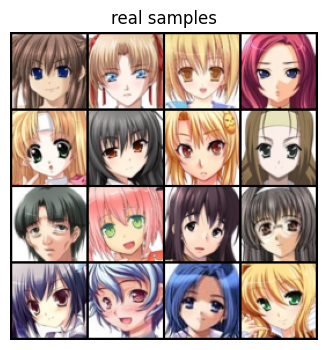

In [22]:
CMAP = "gray" if CHANNELS == 1 else None


def show_grid(img_grid, title=None, save=None, figsize=(4, 4)):
    arr = img_grid.permute(1, 2, 0)
    if CHANNELS == 1:
        arr = arr.squeeze()
    plt.figure(figsize=figsize)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.imshow(arr, cmap=CMAP)
    if save:
        plt.savefig(save, bbox_inches="tight")
    plt.show()


real_batch, _ = next(iter(dataloader))
show_grid(make_grid(real_batch[:16], nrow=4, normalize=True), title="real samples")

## Evaluation metrics — FID & Inception Score

In [23]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore


@torch.no_grad()
def compute_fid_is(gen, n_samples=2048, batch=128):
    """FID (lower better) and Inception Score (higher better) for a generator.
    Inception wants 3-channel [0,1] images; we un-normalize from [-1,1] and
    expand grayscale. FID on MNIST is unconventional but a valid relative signal."""
    fid = FrechetInceptionDistance(normalize=True).to(device)
    iscore = InceptionScore(normalize=True).to(device)
    gen.eval()

    def prep(x):
        x = (x.clamp(-1, 1) + 1) / 2
        return x.repeat(1, 3, 1, 1) if x.size(1) == 1 else x

    seen = 0
    for real, _ in dataloader:
        fid.update(prep(real.to(device)), real=True)
        seen += real.size(0)
        if seen >= n_samples:
            break
    seen = 0
    while seen < n_samples:
        z = torch.randn(batch, NZ, 1, 1, device=device)
        fake = prep(gen(z))
        fid.update(fake, real=False)
        iscore.update(fake)
        seen += batch
    gen.train()
    return fid.compute().item(), iscore.compute()[0].item()

## Training engine (checkpoint-resumable, one function per architecture)

In [24]:
import json


def gradient_penalty(critic, real, fake):
    bs = real.size(0)
    eps = torch.rand(bs, 1, 1, 1, device=real.device)
    interp = (eps * real + (1 - eps) * fake).requires_grad_(True)
    scores = critic(interp)
    grads = torch.autograd.grad(
        outputs=scores, inputs=interp, grad_outputs=torch.ones_like(scores),
        create_graph=True, retain_graph=True, only_inputs=True)[0]
    grads = grads.reshape(bs, -1)
    return ((grads.norm(2, dim=1) - 1) ** 2).mean()


def build_models(arch):
    G = Generator(img_size=IMG_SIZE, nz=NZ, channels=CHANNELS).to(device)
    D = (Critic if arch == "wgan_gp" else Discriminator)(img_size=IMG_SIZE, channels=CHANNELS).to(device)
    G.apply(weights_init)
    D.apply(weights_init)
    return G, D


def train_gan(arch, epochs, checkpoint_every=5, fid_samples=2048, n_critic=5, gp_lambda=10.0):
    """Train one architecture end-to-end with checkpoint-resume. Saves per-arch
    final + best-FID generators, samples, and history. Returns the history dict."""
    ckpt_path = os.path.join(CKPT_DIR, f"{PREFIX}_{arch}_checkpoint.pth")
    best_path = os.path.join(WEIGHTS_DIR, f"{PREFIX}_{arch}_generator_best.pth")
    final_path = os.path.join(WEIGHTS_DIR, f"{PREFIX}_{arch}_generator.pth")
    hist_path = os.path.join(SAMPLES_DIR, f"{PREFIX}_{arch}_history.json")

    G, D = build_models(arch)
    betas = (0.5, 0.9) if arch == "wgan_gp" else BETAS
    optG = torch.optim.Adam(G.parameters(), lr=LR, betas=betas)
    optD = torch.optim.Adam(D.parameters(), lr=LR, betas=betas)
    use_amp = (device.type == "cuda") and (arch != "wgan_gp")  # GP needs fp32 double-backward
    scalerG, scalerD = make_scaler(use_amp), make_scaler(use_amp)
    fixed_noise = torch.randn(16, NZ, 1, 1, device=device)

    history = {"g_loss": [], "d_loss": [], "dx": [], "dgz": [], "fid": []}
    start_epoch, best_fid = 0, float("inf")
    if os.path.exists(ckpt_path):
        ck = torch.load(ckpt_path, map_location=device)
        G.load_state_dict(ck["G"]); D.load_state_dict(ck["D"])
        optG.load_state_dict(ck["optG"]); optD.load_state_dict(ck["optD"])
        start_epoch, best_fid, history = ck["epoch"] + 1, ck["best_fid"], ck["history"]
        fixed_noise = ck["fixed_noise"].to(device)
        print(f"[{arch}] resumed at epoch {start_epoch} (best FID {best_fid:.2f})")

    if start_epoch >= epochs:
        print(f"[{arch}] already complete — skipping")
        return history

    bce, mse = torch.nn.BCEWithLogitsLoss(), torch.nn.MSELoss()

    for epoch in range(start_epoch, epochs):
        gl = dl = dx = dgz = 0.0
        nb = 0
        for real, _ in dataloader:
            real = real.to(device)
            bs = real.size(0)

            if arch == "wgan_gp":
                for _ in range(n_critic):
                    fake = G(torch.randn(bs, NZ, 1, 1, device=device)).detach()
                    d_real, d_fake = D(real).mean(), D(fake).mean()
                    lossD = d_fake - d_real + gp_lambda * gradient_penalty(D, real.data, fake.data)
                    optD.zero_grad(); lossD.backward(); optD.step()
                fake = G(torch.randn(bs, NZ, 1, 1, device=device))
                lossG = -D(fake).mean()
                optG.zero_grad(); lossG.backward(); optG.step()
                dx += d_real.item(); dgz += d_fake.item()
            else:
                optD.zero_grad()
                with amp_autocast(use_amp):
                    fake = G(torch.randn(bs, NZ, 1, 1, device=device))
                    out_real, out_fake = D(real), D(fake.detach())
                    if arch == "dcgan":
                        lossD = bce(out_real, torch.full((bs,), 0.9, device=device)) + \
                                bce(out_fake, torch.zeros(bs, device=device))
                    else:  # lsgan
                        lossD = mse(out_real, torch.ones(bs, device=device)) + \
                                mse(out_fake, torch.zeros(bs, device=device))
                scalerD.scale(lossD).backward(); scalerD.step(optD); scalerD.update()

                optG.zero_grad()
                with amp_autocast(use_amp):
                    out = D(fake)
                    tgt = torch.ones(bs, device=device)
                    lossG = bce(out, tgt) if arch == "dcgan" else mse(out, tgt)
                scalerG.scale(lossG).backward(); scalerG.step(optG); scalerG.update()
                dx += torch.sigmoid(out_real.detach()).mean().item()
                dgz += torch.sigmoid(out_fake.detach()).mean().item()

            gl += lossG.item(); dl += lossD.item(); nb += 1

        history["g_loss"].append(gl / nb); history["d_loss"].append(dl / nb)
        history["dx"].append(dx / nb); history["dgz"].append(dgz / nb)
        extra = "" if arch == "wgan_gp" else f"  D(x)={dx / nb:.3f}  D(G(z))={dgz / nb:.3f}"
        print(f"[{arch}] epoch {epoch + 1}/{epochs}  loss_g={gl / nb:.3f}  loss_d={dl / nb:.3f}{extra}")

        if (epoch + 1) == 1 or (epoch + 1) % checkpoint_every == 0 or (epoch + 1) == epochs:
            G.eval()
            with torch.no_grad():
                samp = G(fixed_noise).cpu()
            G.train()
            show_grid(make_grid(samp, nrow=4, normalize=True), title=f"{arch} — epoch {epoch + 1}",
                      save=os.path.join(SAMPLES_DIR, f"{PREFIX}_{arch}_epoch{epoch + 1:03d}.png"))
            fid, isc = compute_fid_is(G, fid_samples)
            history["fid"].append((epoch + 1, fid, isc))
            print(f"    [{arch}] FID={fid:.2f}  IS={isc:.2f}")
            if fid < best_fid:
                best_fid = fid
                torch.save(G.state_dict(), best_path)
            torch.save({"epoch": epoch, "best_fid": best_fid, "history": history,
                        "G": G.state_dict(), "D": D.state_dict(),
                        "optG": optG.state_dict(), "optD": optD.state_dict(),
                        "fixed_noise": fixed_noise.cpu()}, ckpt_path)
            json.dump(history, open(hist_path, "w"))

    torch.save(G.state_dict(), final_path)
    print(f"[{arch}] done — final {final_path} | best (FID {best_fid:.2f}) {best_path}")
    return history

## Train all architectures

training dcgan
[dcgan] resumed at epoch 1 (best FID 297.81)
[dcgan] epoch 2/60  loss_g=4.958  loss_d=0.924  D(x)=0.723  D(G(z))=0.183
[dcgan] epoch 3/60  loss_g=5.503  loss_d=0.850  D(x)=0.726  D(G(z))=0.172
[dcgan] epoch 4/60  loss_g=5.262  loss_d=0.788  D(x)=0.736  D(G(z))=0.160
[dcgan] epoch 5/60  loss_g=5.147  loss_d=0.845  D(x)=0.714  D(G(z))=0.182


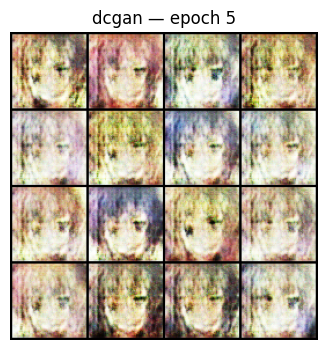

    [dcgan] FID=361.43  IS=1.95
[dcgan] epoch 6/60  loss_g=4.993  loss_d=0.764  D(x)=0.731  D(G(z))=0.162
[dcgan] epoch 7/60  loss_g=4.904  loss_d=0.789  D(x)=0.735  D(G(z))=0.163
[dcgan] epoch 8/60  loss_g=5.013  loss_d=0.737  D(x)=0.748  D(G(z))=0.151
[dcgan] epoch 9/60  loss_g=4.889  loss_d=0.708  D(x)=0.758  D(G(z))=0.140
[dcgan] epoch 10/60  loss_g=4.857  loss_d=0.725  D(x)=0.763  D(G(z))=0.136


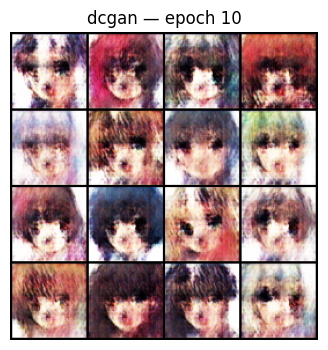

    [dcgan] FID=328.27  IS=2.66
[dcgan] epoch 11/60  loss_g=4.623  loss_d=0.762  D(x)=0.748  D(G(z))=0.152
[dcgan] epoch 12/60  loss_g=4.731  loss_d=0.699  D(x)=0.759  D(G(z))=0.137
[dcgan] epoch 13/60  loss_g=4.709  loss_d=0.692  D(x)=0.767  D(G(z))=0.131
[dcgan] epoch 14/60  loss_g=4.632  loss_d=0.716  D(x)=0.771  D(G(z))=0.135
[dcgan] epoch 15/60  loss_g=4.404  loss_d=0.698  D(x)=0.758  D(G(z))=0.138


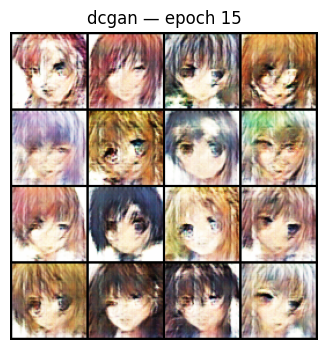

    [dcgan] FID=221.87  IS=2.95
[dcgan] epoch 16/60  loss_g=4.531  loss_d=0.697  D(x)=0.762  D(G(z))=0.138
[dcgan] epoch 17/60  loss_g=4.367  loss_d=0.665  D(x)=0.768  D(G(z))=0.131
[dcgan] epoch 18/60  loss_g=4.415  loss_d=0.757  D(x)=0.746  D(G(z))=0.153
[dcgan] epoch 19/60  loss_g=4.220  loss_d=0.695  D(x)=0.758  D(G(z))=0.141
[dcgan] epoch 20/60  loss_g=4.147  loss_d=0.714  D(x)=0.754  D(G(z))=0.144


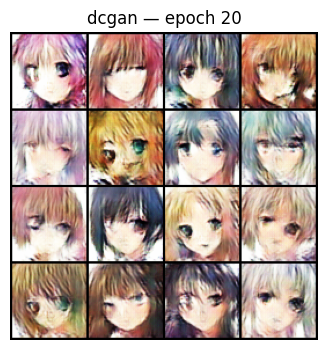

    [dcgan] FID=155.56  IS=2.42
[dcgan] epoch 21/60  loss_g=4.197  loss_d=0.707  D(x)=0.753  D(G(z))=0.147
[dcgan] epoch 22/60  loss_g=4.015  loss_d=0.706  D(x)=0.752  D(G(z))=0.148
[dcgan] epoch 23/60  loss_g=3.946  loss_d=0.706  D(x)=0.752  D(G(z))=0.146
[dcgan] epoch 24/60  loss_g=3.829  loss_d=0.750  D(x)=0.747  D(G(z))=0.154
[dcgan] epoch 25/60  loss_g=3.861  loss_d=0.700  D(x)=0.756  D(G(z))=0.144


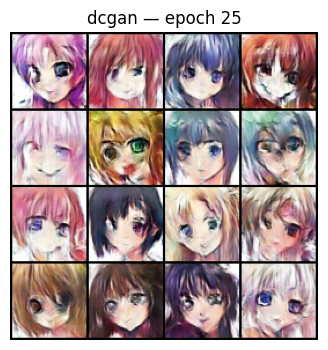

    [dcgan] FID=137.09  IS=2.51
[dcgan] epoch 26/60  loss_g=3.845  loss_d=0.698  D(x)=0.752  D(G(z))=0.147
[dcgan] epoch 27/60  loss_g=3.725  loss_d=0.707  D(x)=0.751  D(G(z))=0.148
[dcgan] epoch 28/60  loss_g=3.620  loss_d=0.723  D(x)=0.746  D(G(z))=0.154
[dcgan] epoch 29/60  loss_g=3.559  loss_d=0.697  D(x)=0.753  D(G(z))=0.147
[dcgan] epoch 30/60  loss_g=3.551  loss_d=0.737  D(x)=0.742  D(G(z))=0.157


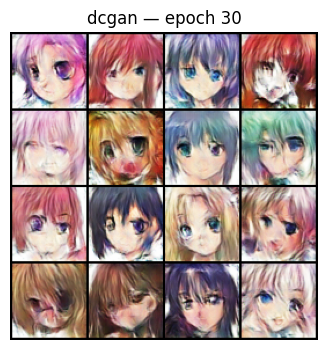

    [dcgan] FID=130.15  IS=2.34
[dcgan] epoch 31/60  loss_g=3.494  loss_d=0.702  D(x)=0.751  D(G(z))=0.147
[dcgan] epoch 32/60  loss_g=3.566  loss_d=0.777  D(x)=0.738  D(G(z))=0.159
[dcgan] epoch 33/60  loss_g=3.432  loss_d=0.684  D(x)=0.755  D(G(z))=0.144
[dcgan] epoch 34/60  loss_g=3.425  loss_d=0.710  D(x)=0.750  D(G(z))=0.151
[dcgan] epoch 35/60  loss_g=3.391  loss_d=0.686  D(x)=0.751  D(G(z))=0.147


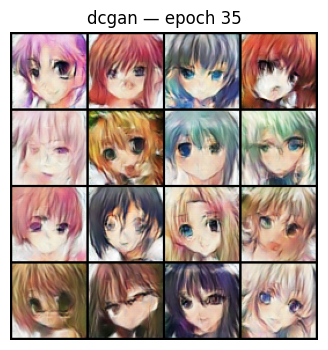

    [dcgan] FID=109.40  IS=2.24
[dcgan] epoch 36/60  loss_g=3.416  loss_d=0.702  D(x)=0.751  D(G(z))=0.149
[dcgan] epoch 37/60  loss_g=3.327  loss_d=0.730  D(x)=0.747  D(G(z))=0.153
[dcgan] epoch 38/60  loss_g=3.219  loss_d=0.759  D(x)=0.741  D(G(z))=0.158
[dcgan] epoch 39/60  loss_g=3.198  loss_d=0.657  D(x)=0.758  D(G(z))=0.141
[dcgan] epoch 40/60  loss_g=3.236  loss_d=0.678  D(x)=0.754  D(G(z))=0.145


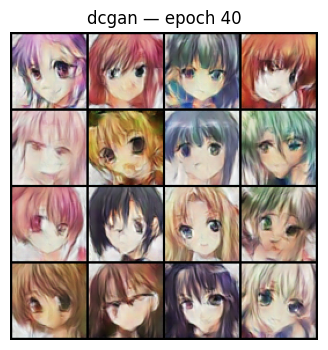

    [dcgan] FID=88.36  IS=2.27
[dcgan] epoch 41/60  loss_g=3.286  loss_d=0.730  D(x)=0.743  D(G(z))=0.157
[dcgan] epoch 42/60  loss_g=3.293  loss_d=0.681  D(x)=0.757  D(G(z))=0.144
[dcgan] epoch 43/60  loss_g=3.250  loss_d=0.687  D(x)=0.755  D(G(z))=0.140
[dcgan] epoch 44/60  loss_g=3.195  loss_d=0.713  D(x)=0.747  D(G(z))=0.152
[dcgan] epoch 45/60  loss_g=3.257  loss_d=0.640  D(x)=0.769  D(G(z))=0.131


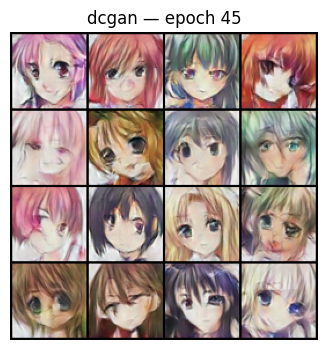

    [dcgan] FID=79.61  IS=2.14
[dcgan] epoch 46/60  loss_g=3.257  loss_d=0.730  D(x)=0.749  D(G(z))=0.149
[dcgan] epoch 47/60  loss_g=3.313  loss_d=0.613  D(x)=0.775  D(G(z))=0.127
[dcgan] epoch 48/60  loss_g=3.334  loss_d=0.675  D(x)=0.766  D(G(z))=0.134
[dcgan] epoch 49/60  loss_g=3.347  loss_d=0.664  D(x)=0.771  D(G(z))=0.130
[dcgan] epoch 50/60  loss_g=3.359  loss_d=0.600  D(x)=0.781  D(G(z))=0.117


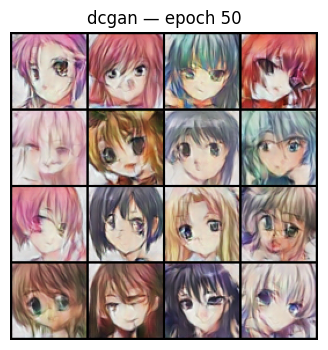

    [dcgan] FID=74.33  IS=2.22
[dcgan] epoch 51/60  loss_g=3.282  loss_d=0.723  D(x)=0.752  D(G(z))=0.148
[dcgan] epoch 52/60  loss_g=3.411  loss_d=0.563  D(x)=0.795  D(G(z))=0.105
[dcgan] epoch 53/60  loss_g=3.348  loss_d=0.693  D(x)=0.768  D(G(z))=0.132
[dcgan] epoch 54/60  loss_g=3.407  loss_d=0.607  D(x)=0.786  D(G(z))=0.113
[dcgan] epoch 55/60  loss_g=3.431  loss_d=0.626  D(x)=0.788  D(G(z))=0.111


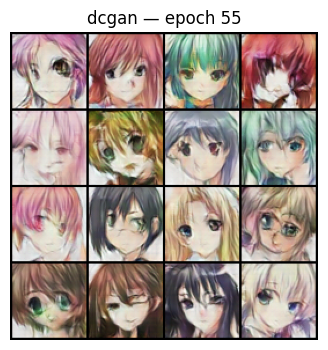

    [dcgan] FID=77.27  IS=2.19
[dcgan] epoch 56/60  loss_g=3.339  loss_d=0.668  D(x)=0.774  D(G(z))=0.127
[dcgan] epoch 57/60  loss_g=3.445  loss_d=0.680  D(x)=0.773  D(G(z))=0.129
[dcgan] epoch 58/60  loss_g=3.465  loss_d=0.519  D(x)=0.810  D(G(z))=0.088
[dcgan] epoch 59/60  loss_g=3.488  loss_d=0.602  D(x)=0.791  D(G(z))=0.109
[dcgan] epoch 60/60  loss_g=3.484  loss_d=0.614  D(x)=0.790  D(G(z))=0.105


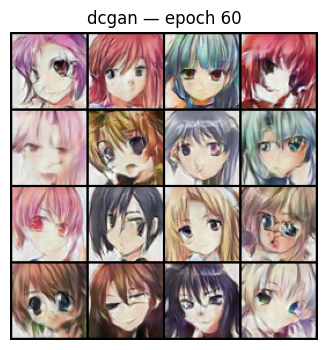

    [dcgan] FID=69.22  IS=2.22
[dcgan] done — final /kaggle/working/weights/anime_dcgan_generator.pth | best (FID 69.22) /kaggle/working/weights/anime_dcgan_generator_best.pth
training lsgan
[lsgan] epoch 1/60  loss_g=18.489  loss_d=6.217  D(x)=0.648  D(G(z))=0.557


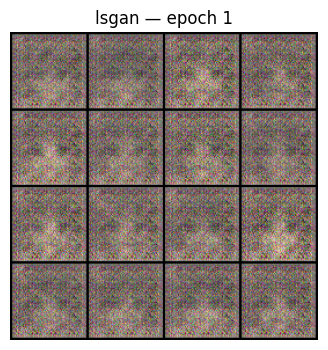

    [lsgan] FID=409.88  IS=1.09
[lsgan] epoch 2/60  loss_g=3.411  loss_d=1.212  D(x)=0.679  D(G(z))=0.541
[lsgan] epoch 3/60  loss_g=1.183  loss_d=0.422  D(x)=0.689  D(G(z))=0.539
[lsgan] epoch 4/60  loss_g=1.070  loss_d=0.369  D(x)=0.693  D(G(z))=0.537
[lsgan] epoch 5/60  loss_g=1.016  loss_d=0.331  D(x)=0.695  D(G(z))=0.536


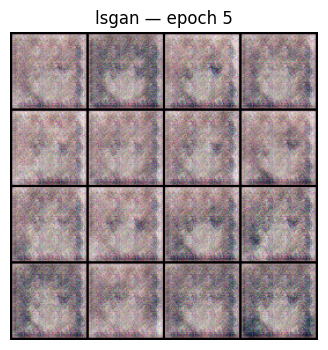

    [lsgan] FID=341.19  IS=1.44
[lsgan] epoch 6/60  loss_g=2.489  loss_d=0.697  D(x)=0.696  D(G(z))=0.532
[lsgan] epoch 7/60  loss_g=3.314  loss_d=0.958  D(x)=0.703  D(G(z))=0.525
[lsgan] epoch 8/60  loss_g=2.233  loss_d=0.629  D(x)=0.708  D(G(z))=0.525
[lsgan] epoch 9/60  loss_g=4.087  loss_d=2.055  D(x)=0.702  D(G(z))=0.529
[lsgan] epoch 10/60  loss_g=0.898  loss_d=0.081  D(x)=0.709  D(G(z))=0.525


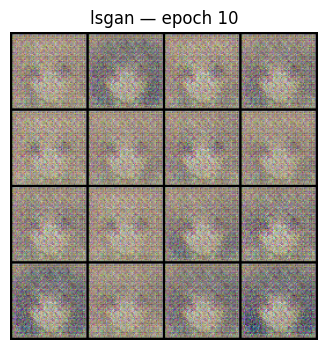

    [lsgan] FID=372.52  IS=1.09
[lsgan] epoch 11/60  loss_g=0.747  loss_d=0.151  D(x)=0.690  D(G(z))=0.545
[lsgan] epoch 12/60  loss_g=0.756  loss_d=0.185  D(x)=0.686  D(G(z))=0.550
[lsgan] epoch 13/60  loss_g=0.826  loss_d=0.217  D(x)=0.687  D(G(z))=0.549
[lsgan] epoch 14/60  loss_g=0.858  loss_d=0.248  D(x)=0.683  D(G(z))=0.553
[lsgan] epoch 15/60  loss_g=0.789  loss_d=0.307  D(x)=0.676  D(G(z))=0.559


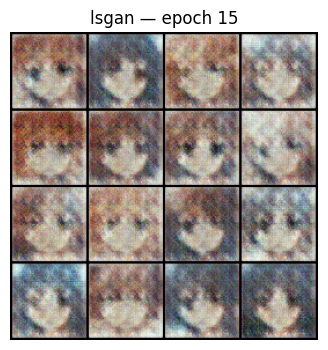

    [lsgan] FID=359.19  IS=2.65
[lsgan] epoch 16/60  loss_g=0.748  loss_d=0.330  D(x)=0.673  D(G(z))=0.563
[lsgan] epoch 17/60  loss_g=0.775  loss_d=0.348  D(x)=0.670  D(G(z))=0.567
[lsgan] epoch 18/60  loss_g=0.839  loss_d=0.322  D(x)=0.676  D(G(z))=0.560
[lsgan] epoch 19/60  loss_g=0.858  loss_d=0.344  D(x)=0.674  D(G(z))=0.562
[lsgan] epoch 20/60  loss_g=0.829  loss_d=0.354  D(x)=0.672  D(G(z))=0.564


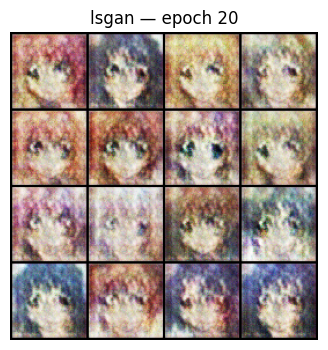

    [lsgan] FID=344.76  IS=1.97
[lsgan] epoch 21/60  loss_g=0.859  loss_d=0.349  D(x)=0.672  D(G(z))=0.563
[lsgan] epoch 22/60  loss_g=0.894  loss_d=0.360  D(x)=0.672  D(G(z))=0.564
[lsgan] epoch 23/60  loss_g=0.924  loss_d=0.365  D(x)=0.671  D(G(z))=0.565
[lsgan] epoch 24/60  loss_g=0.932  loss_d=0.367  D(x)=0.671  D(G(z))=0.564
[lsgan] epoch 25/60  loss_g=0.997  loss_d=0.355  D(x)=0.675  D(G(z))=0.560


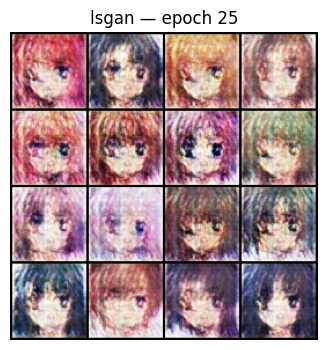

    [lsgan] FID=346.54  IS=2.80
[lsgan] epoch 26/60  loss_g=1.017  loss_d=0.352  D(x)=0.674  D(G(z))=0.561
[lsgan] epoch 27/60  loss_g=1.032  loss_d=0.353  D(x)=0.674  D(G(z))=0.562
[lsgan] epoch 28/60  loss_g=1.063  loss_d=0.359  D(x)=0.673  D(G(z))=0.563
[lsgan] epoch 29/60  loss_g=1.057  loss_d=0.355  D(x)=0.673  D(G(z))=0.562
[lsgan] epoch 30/60  loss_g=1.055  loss_d=0.339  D(x)=0.674  D(G(z))=0.562


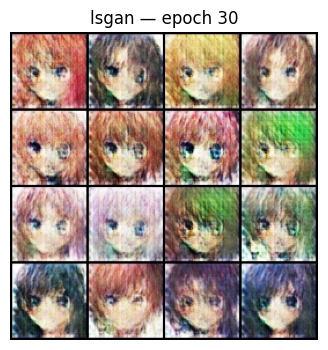

    [lsgan] FID=314.40  IS=3.21
[lsgan] epoch 31/60  loss_g=1.129  loss_d=0.352  D(x)=0.674  D(G(z))=0.562
[lsgan] epoch 32/60  loss_g=1.133  loss_d=0.347  D(x)=0.674  D(G(z))=0.561
[lsgan] epoch 33/60  loss_g=1.138  loss_d=0.340  D(x)=0.676  D(G(z))=0.560
[lsgan] epoch 34/60  loss_g=1.149  loss_d=0.328  D(x)=0.677  D(G(z))=0.558
[lsgan] epoch 35/60  loss_g=1.123  loss_d=0.321  D(x)=0.676  D(G(z))=0.559


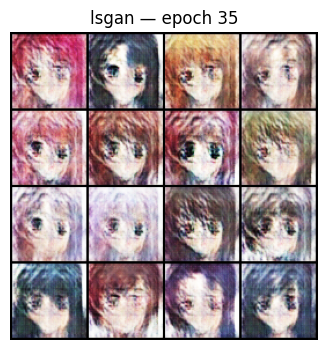

    [lsgan] FID=305.56  IS=3.19
[lsgan] epoch 36/60  loss_g=1.164  loss_d=0.330  D(x)=0.677  D(G(z))=0.559
[lsgan] epoch 37/60  loss_g=1.136  loss_d=0.345  D(x)=0.674  D(G(z))=0.562
[lsgan] epoch 38/60  loss_g=1.179  loss_d=0.331  D(x)=0.677  D(G(z))=0.558
[lsgan] epoch 39/60  loss_g=1.207  loss_d=0.291  D(x)=0.681  D(G(z))=0.554
[lsgan] epoch 40/60  loss_g=1.174  loss_d=0.302  D(x)=0.681  D(G(z))=0.554


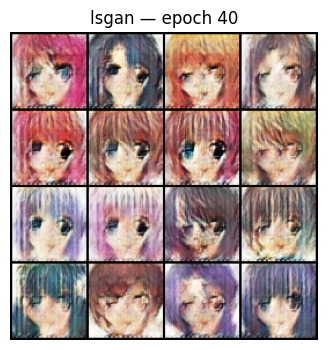

    [lsgan] FID=256.92  IS=2.83
[lsgan] epoch 41/60  loss_g=1.197  loss_d=0.280  D(x)=0.682  D(G(z))=0.553
[lsgan] epoch 42/60  loss_g=1.206  loss_d=0.320  D(x)=0.680  D(G(z))=0.555
[lsgan] epoch 43/60  loss_g=1.207  loss_d=0.282  D(x)=0.683  D(G(z))=0.552
[lsgan] epoch 44/60  loss_g=1.211  loss_d=0.266  D(x)=0.686  D(G(z))=0.549
[lsgan] epoch 45/60  loss_g=1.189  loss_d=0.265  D(x)=0.685  D(G(z))=0.549


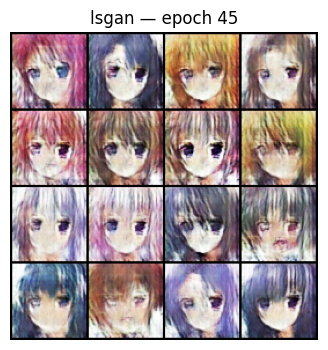

    [lsgan] FID=236.90  IS=2.44
[lsgan] epoch 46/60  loss_g=1.223  loss_d=0.267  D(x)=0.687  D(G(z))=0.548
[lsgan] epoch 47/60  loss_g=1.174  loss_d=0.279  D(x)=0.685  D(G(z))=0.550
[lsgan] epoch 48/60  loss_g=1.153  loss_d=0.279  D(x)=0.683  D(G(z))=0.552
[lsgan] epoch 49/60  loss_g=1.142  loss_d=0.252  D(x)=0.686  D(G(z))=0.549
[lsgan] epoch 50/60  loss_g=1.143  loss_d=0.277  D(x)=0.685  D(G(z))=0.550


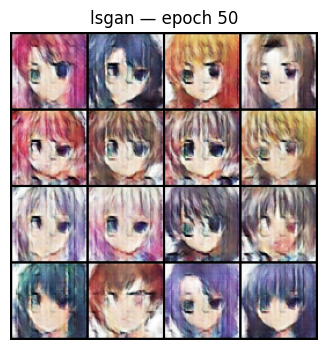

    [lsgan] FID=195.96  IS=2.56
[lsgan] epoch 51/60  loss_g=1.115  loss_d=0.269  D(x)=0.685  D(G(z))=0.551
[lsgan] epoch 52/60  loss_g=1.178  loss_d=0.277  D(x)=0.683  D(G(z))=0.550
[lsgan] epoch 53/60  loss_g=1.132  loss_d=0.267  D(x)=0.687  D(G(z))=0.549
[lsgan] epoch 54/60  loss_g=1.162  loss_d=0.258  D(x)=0.686  D(G(z))=0.547
[lsgan] epoch 55/60  loss_g=1.075  loss_d=0.262  D(x)=0.685  D(G(z))=0.552


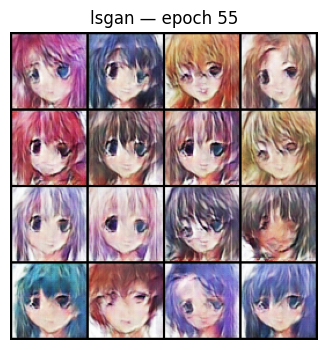

    [lsgan] FID=166.36  IS=2.42
[lsgan] epoch 56/60  loss_g=1.078  loss_d=0.237  D(x)=0.687  D(G(z))=0.549
[lsgan] epoch 57/60  loss_g=1.107  loss_d=0.254  D(x)=0.688  D(G(z))=0.547
[lsgan] epoch 58/60  loss_g=1.083  loss_d=0.241  D(x)=0.689  D(G(z))=0.546
[lsgan] epoch 59/60  loss_g=1.069  loss_d=0.284  D(x)=0.682  D(G(z))=0.553
[lsgan] epoch 60/60  loss_g=1.095  loss_d=0.238  D(x)=0.688  D(G(z))=0.546


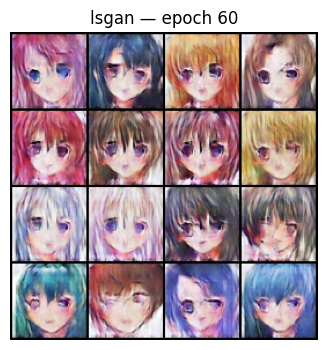

    [lsgan] FID=166.24  IS=2.55
[lsgan] done — final /kaggle/working/weights/anime_lsgan_generator.pth | best (FID 166.24) /kaggle/working/weights/anime_lsgan_generator_best.pth


In [25]:
histories = {}
for arch in ARCHITECTURES:
    print("=" * 60, f"\ntraining {arch}\n" + "=" * 60)
    histories[arch] = train_gan(arch, EPOCHS, checkpoint_every=CKPT_EVERY,
                                fid_samples=FID_SAMPLES, n_critic=N_CRITIC)

## Architecture comparison + pick the winner

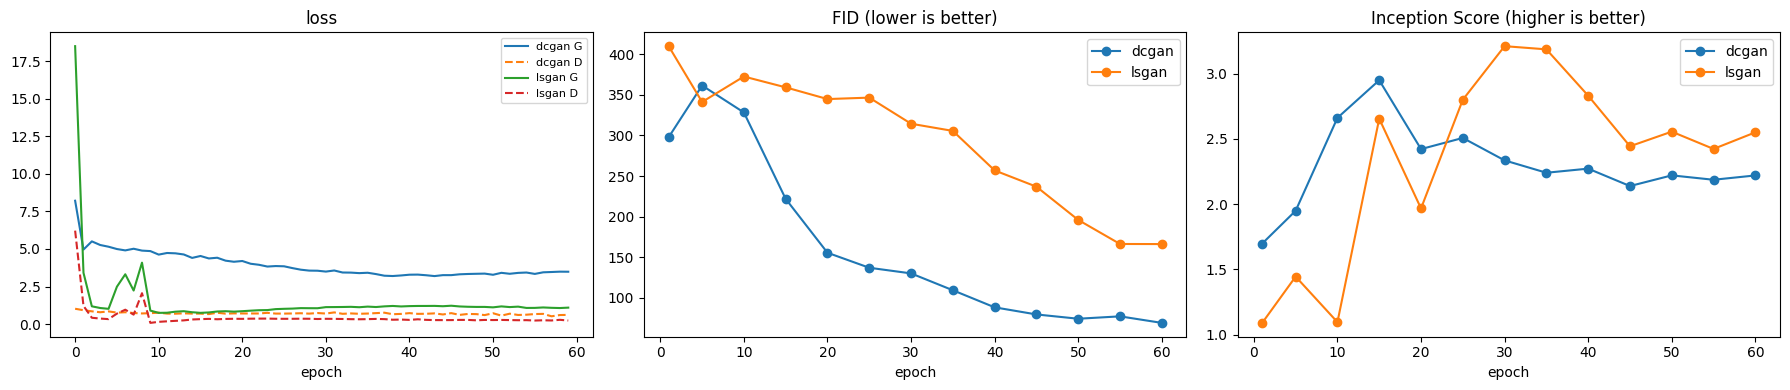

architecture    best FID  final FID  final IS
dcgan              69.22      69.22      2.22
lsgan             166.24     166.24      2.55

WINNER: dcgan  (best FID 69.22)
deployment default -> anime_generator.pth (dcgan); winners.json updated


In [26]:
# ---- overlay curves ----
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
for arch in ARCHITECTURES:
    h = histories[arch]
    ax[0].plot(h["g_loss"], label=f"{arch} G")
    ax[0].plot(h["d_loss"], "--", label=f"{arch} D")
    if h["fid"]:
        ep, fids, iss = zip(*h["fid"])
        ax[1].plot(ep, fids, marker="o", label=arch)
        ax[2].plot(ep, iss, marker="o", label=arch)
ax[0].set_title("loss"); ax[0].set_xlabel("epoch"); ax[0].legend(fontsize=8)
ax[1].set_title("FID (lower is better)"); ax[1].set_xlabel("epoch"); ax[1].legend()
ax[2].set_title("Inception Score (higher is better)"); ax[2].set_xlabel("epoch"); ax[2].legend()
plt.tight_layout(); plt.show()

# ---- summary table + winner (lowest best-FID) ----
print(f"{'architecture':14}{'best FID':>10}{'final FID':>11}{'final IS':>10}")
winner, winner_fid = None, float("inf")
for arch in ARCHITECTURES:
    h = histories[arch]["fid"]
    if not h:
        continue
    fids = [f for _, f, _ in h]
    best = min(fids)
    print(f"{arch:14}{best:10.2f}{fids[-1]:11.2f}{h[-1][2]:10.2f}")
    if best < winner_fid:
        winner, winner_fid = arch, best
print(f"\nWINNER: {winner}  (best FID {winner_fid:.2f})")

# ---- promote winner to the deployment weight + record it ----
import shutil
shutil.copy(os.path.join(WEIGHTS_DIR, f"{PREFIX}_{winner}_generator_best.pth"),
            os.path.join(WEIGHTS_DIR, f"{PREFIX}_generator.pth"))
wp = os.path.join(WEIGHTS_DIR, "winners.json")
winners = json.load(open(wp)) if os.path.exists(wp) else {}
winners[PREFIX] = winner
json.dump(winners, open(wp, "w"))
print(f"deployment default -> {PREFIX}_generator.pth ({winner}); winners.json updated")

## Best-generator grids, side by side

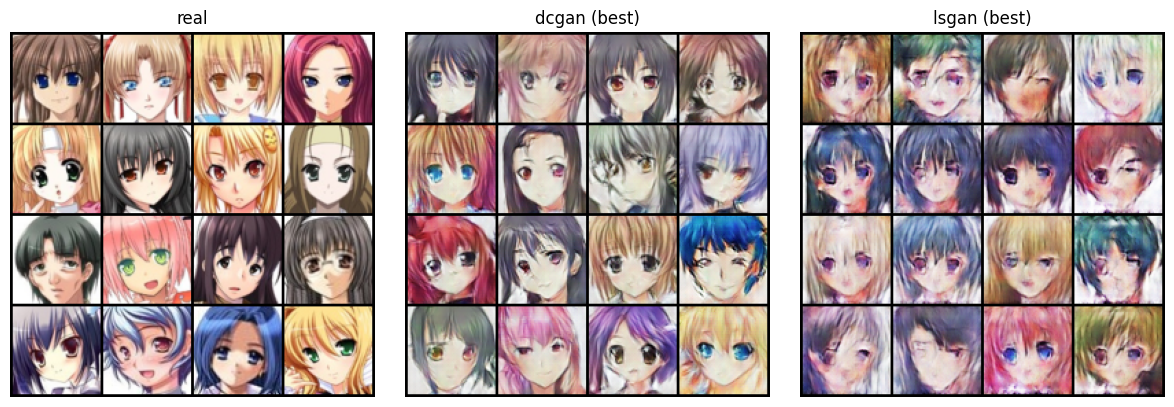

In [27]:
fig, axes = plt.subplots(1, len(ARCHITECTURES) + 1, figsize=(4 * (len(ARCHITECTURES) + 1), 4))
axes[0].imshow(make_grid(real_batch[:16], nrow=4, normalize=True).permute(1, 2, 0).squeeze(), cmap=CMAP)
axes[0].set_title("real"); axes[0].axis("off")
for ax, arch in zip(axes[1:], ARCHITECTURES):
    g = Generator(img_size=IMG_SIZE, nz=NZ, channels=CHANNELS).to(device)
    g.load_state_dict(torch.load(os.path.join(WEIGHTS_DIR, f"{PREFIX}_{arch}_generator_best.pth"),
                                 map_location=device))
    g.eval()
    with torch.no_grad():
        samp = g(torch.randn(16, NZ, 1, 1, device=device)).cpu()
    ax.imshow(make_grid(samp, nrow=4, normalize=True).permute(1, 2, 0).squeeze(), cmap=CMAP)
    ax.set_title(f"{arch} (best)"); ax.axis("off")
plt.tight_layout(); plt.savefig(os.path.join(SAMPLES_DIR, f"{PREFIX}_architecture_comparison.png")); plt.show()